<a href="https://colab.research.google.com/github/priyansh-commits/practice/blob/main/Decision_Tree_Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [171]:
# 1. Problem Statement

# 2. Classification
#    2.1 Import libraries
#    2.2 Load dataset
#    2.3 EDA
#    2.4 Data preprocessing
#    2.5 Train-test split
#    2.6 Baseline Decision Tree
#    2.7 Evaluation
#    2.8 Visualize tree
#    2.9 Feature importance
#    2.10 Hyperparameter tuning
#    2.11 Compare before vs after tuning

# 3. Regression
#    3.1 Load dataset
#    3.2 EDA
#    3.3 Train-test split
#    3.4 Baseline Decision Tree
#    3.5 Evaluation
#    3.6 Feature importance
#    3.7 Hyperparameter tuning
#    3.8 Actual vs predicted
#    3.9 Extrapolation experiment

# 4. Final Comparison

# 5. What I Learned

In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [173]:
df = sns.load_dataset("titanic").drop('alive',axis=1)

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,True


In [174]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['survived']=le.fit_transform(df['survived'])

X=df


In [175]:
y.value_counts()

,count
survived,
0,458
1,322


In [176]:
X.shape

(891, 14)

In [177]:
X.isna().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [178]:
X.drop('deck',axis=1,inplace=True)
X['age'].fillna(X['age'].mean(),inplace=True)
X['embarked'].fillna(X['embarked'].mode()[0],inplace=True)
X['embark_town'].fillna(X['embark_town'].mode()[0],inplace=True)

/tmp/ipykernel_1497/2508846860.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['age'].fillna(X['age'].mean(),inplace=True)
/tmp/ipykernel_1497/2508846860.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [179]:
X.isna().sum().sum()

np.int64(0)

In [180]:
y.isna().sum()

np.int64(0)

In [181]:
X.duplicated().sum()
X.drop_duplicates(inplace=True)
X.describe()


,survived,pclass,age,sibsp,parch,fare
count,780.000000,780.000000,780.000000,780.000000,780.000000,780.000000
mean,0.412821,2.246154,29.797600,0.525641,0.417949,34.829108
std,0.492657,0.854452,13.708883,0.988046,0.838536,52.263440
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,21.750000,0.000000,0.000000,8.050000
50%,0.000000,3.000000,29.699118,0.000000,0.000000,15.950000
75%,1.000000,3.000000,36.000000,1.000000,1.000000,34.375000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [182]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 780 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     780 non-null    int64   
 1   pclass       780 non-null    int64   
 2   sex          780 non-null    object  
 3   age          780 non-null    float64 
 4   sibsp        780 non-null    int64   
 5   parch        780 non-null    int64   
 6   fare         780 non-null    float64 
 7   embarked     780 non-null    object  
 8   class        780 non-null    category
 9   who          780 non-null    object  
 10  adult_male   780 non-null    bool    
 11  embark_town  780 non-null    object  
 12  alone        780 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(4)
memory usage: 69.4+ KB


In [183]:
for i in ['sex','embarked','class','who','adult_male','embark_town','alone']:
    X[i]=le.fit_transform(X[i])
y=X['survived']
X=X.drop('survived',axis=1)


In [184]:
X

,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alone
0,3,1,22.000000,1,0,7.2500,2,2,1,1,2,0
1,1,0,38.000000,1,0,71.2833,0,0,2,0,0,0
2,3,0,26.000000,0,0,7.9250,2,2,2,0,2,1
3,1,0,35.000000,1,0,53.1000,2,0,2,0,2,0
4,3,1,35.000000,0,0,8.0500,2,2,1,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
885,3,0,39.000000,0,5,29.1250,1,2,2,0,1,0
887,1,0,19.000000,0,0,30.0000,2,0,2,0,2,1
888,3,0,29.699118,1,2,23.4500,2,2,2,0,2,0
889,1,1,26.000000,0,0,30.0000,0,0,1,1,0,1


In [185]:
X.describe()

,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alone
count,780.000000,780.000000,780.000000,780.000000,780.000000,780.000000,780.000000,780.000000,780.000000,780.000000,780.000000,780.000000
mean,2.246154,0.625641,29.797600,0.525641,0.417949,34.829108,1.528205,1.246154,1.215385,0.574359,1.528205,0.566667
std,0.854452,0.484267,13.708883,0.988046,0.838536,52.263440,0.804655,0.854452,0.616228,0.494757,0.804655,0.495854
min,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,21.750000,0.000000,0.000000,8.050000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000
50%,3.000000,1.000000,29.699118,0.000000,0.000000,15.950000,2.000000,2.000000,1.000000,1.000000,2.000000,1.000000
75%,3.000000,1.000000,36.000000,1.000000,1.000000,34.375000,2.000000,2.000000,2.000000,1.000000,2.000000,1.000000
max,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200,2.000000,2.000000,2.000000,1.000000,2.000000,1.000000


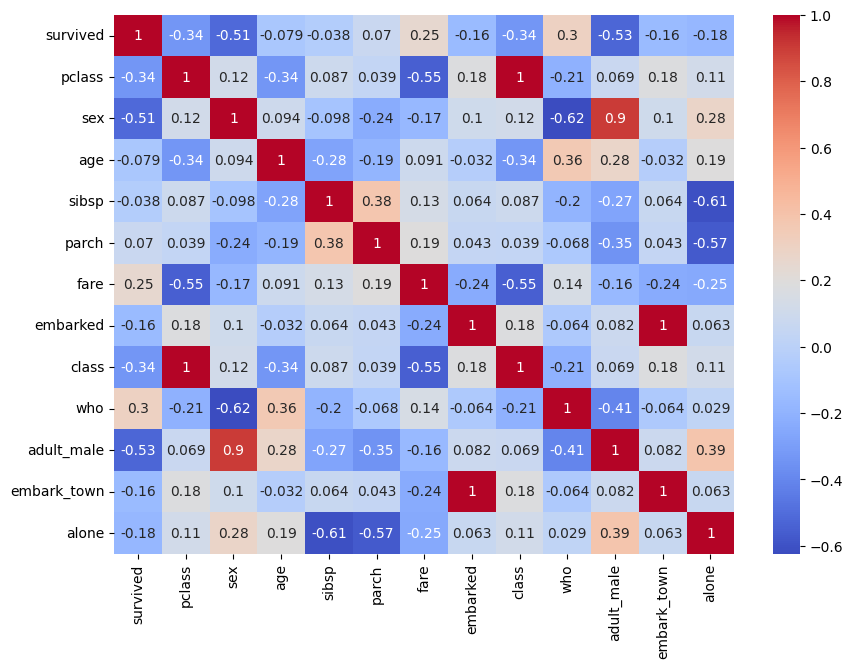

In [186]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [187]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf=DecisionTreeClassifier()
clf.fit(X_train,y_train)
y_pred=clf.predict(X_test)


In [188]:
# accuracy_score,
#     precision_score,
#     recall_score,
#     f1_score,
#     confusion_matrix,
#     classification_report
print("Accuracy:",accuracy_score(y_test, y_pred))
print("Precision:",precision_score(y_test, y_pred))
print("Recall:",recall_score(y_test, y_pred))
print("F1 Score:",f1_score(y_test, y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test, y_pred))
print("Classification Report:\n",classification_report(y_test, y_pred))


Accuracy: 0.7435897435897436
Precision: 0.7049180327868853
Recall: 0.6615384615384615
F1 Score: 0.6825396825396826
Confusion Matrix:
 [[73 18]
 [22 43]]
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.80      0.78        91
           1       0.70      0.66      0.68        65

    accuracy                           0.74       156
   macro avg       0.74      0.73      0.73       156
weighted avg       0.74      0.74      0.74       156



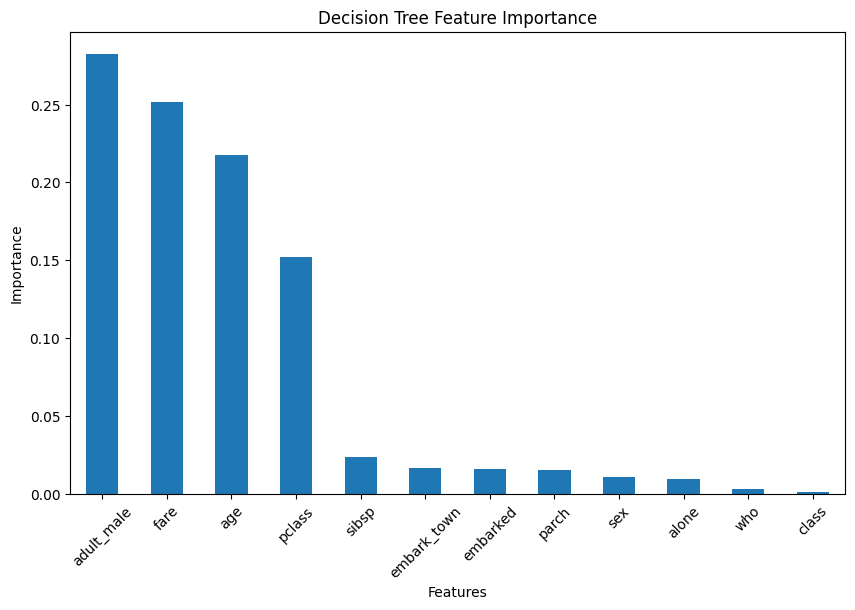

In [189]:
# Feature importance
importance = pd.Series(
    clf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importance.plot(kind='bar')
plt.title("Decision Tree Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

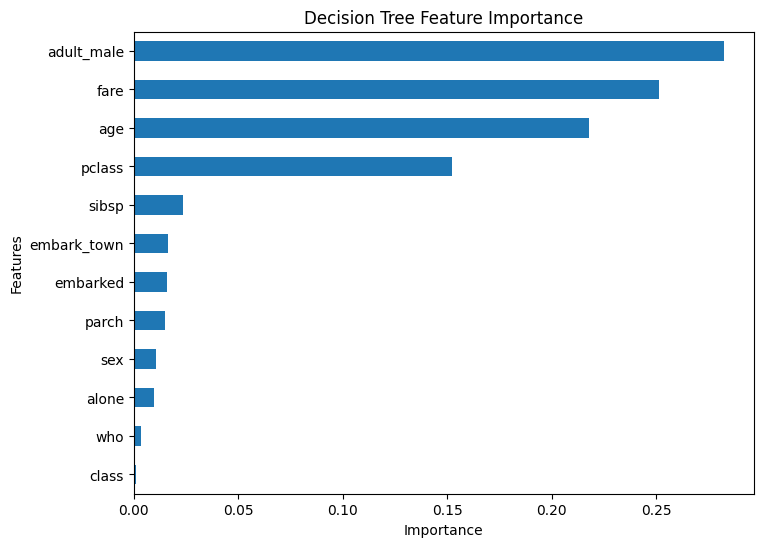

In [190]:
importance.sort_values().plot(kind='barh', figsize=(8, 6))

plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

In [205]:
l = importance.head(6).index.to_list()

X_new=X[l]
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.2, random_state=42)
clf=DecisionTreeClassifier()
clf.fit(X_train,y_train)
y_pred=clf.predict(X_test)

print("Accuracy:",accuracy_score(y_test, y_pred))
print("Precision:",precision_score(y_test, y_pred))
print("Recall:",recall_score(y_test, y_pred))
print("F1 Score:",f1_score(y_test, y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test, y_pred))
print("Classification Report:\n",classification_report(y_test, y_pred))



Accuracy: 0.7307692307692307
Precision: 0.676923076923077
Recall: 0.676923076923077
F1 Score: 0.676923076923077
Confusion Matrix:
 [[70 21]
 [21 44]]
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.77      0.77        91
           1       0.68      0.68      0.68        65

    accuracy                           0.73       156
   macro avg       0.72      0.72      0.72       156
weighted avg       0.73      0.73      0.73       156



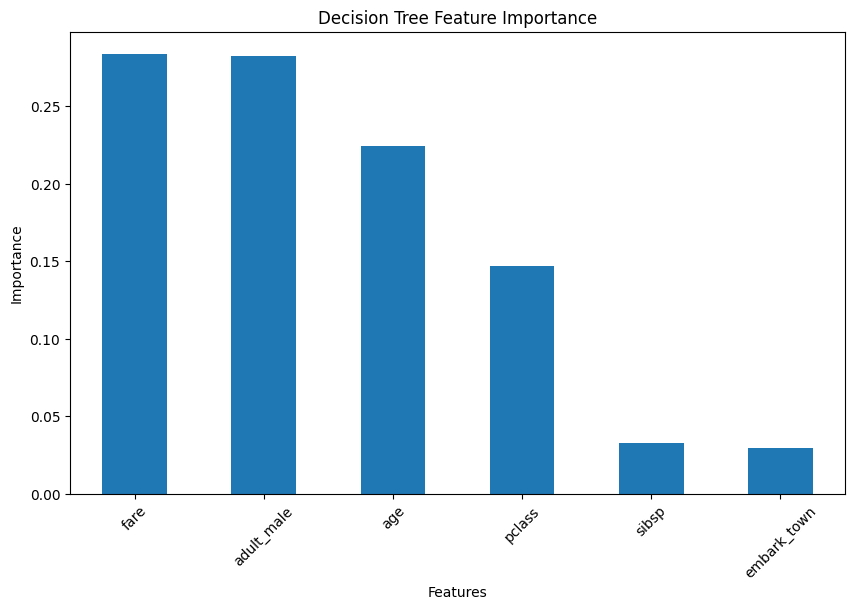

In [206]:
importance = pd.Series(
    clf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importance.plot(kind='bar')
plt.title("Decision Tree Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

In [222]:
from sklearn.model_selection import GridSearchCV
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

param_grid = {
    'max_depth': [3, 4, 5, 6, 8, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy', 'log_loss']
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

In [216]:
best_model = grid.best_estimator_

print("Train:", best_model.score(X_train, y_train))
print("Test :", best_model.score(X_test, y_test))

Train: 0.8589743589743589
Test : 0.7756410256410257


In [219]:
from sklearn.model_selection import GridSearchCV
X_train1, X_test1, y_train, y_test = train_test_split(X_new, y, test_size=0.2, random_state=42)

param_grid = {
    'max_depth': [3, 4, 5, 6, 8, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy', 'log_loss']
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

In [214]:
best_model = grid.best_estimator_

print("Train:", best_model.score(X_train, y_train))
print("Test :", best_model.score(X_test, y_test))

Train: 0.8573717948717948
Test : 0.7756410256410257


In [217]:
from sklearn.metrics import classification_report

print(classification_report(y_test, best_model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.79      0.84      0.81        91
           1       0.75      0.69      0.72        65

    accuracy                           0.78       156
   macro avg       0.77      0.76      0.77       156
weighted avg       0.77      0.78      0.77       156



In [225]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

path = dt.cost_complexity_pruning_path(
    X_train, y_train
)

alphas = path.ccp_alphas
for alpha in alphas:
    dt = DecisionTreeClassifier(
        random_state=42,
        ccp_alpha=alpha
    )

    dt.fit(X_train, y_train)

    print(
        alpha,
        "Train:", dt.score(X_train, y_train),
        "Test:", dt.score(X_test, y_test)
    )

0.0 Train: 0.9823717948717948 Test: 0.75
0.0004856254856254861 Train: 0.9823717948717948 Test: 0.75
0.000534188034188034 Train: 0.9823717948717948 Test: 0.75
0.000534188034188034 Train: 0.9823717948717948 Test: 0.75
0.000534188034188034 Train: 0.9823717948717948 Test: 0.75
0.000534188034188034 Train: 0.9823717948717948 Test: 0.75
0.000534188034188034 Train: 0.9823717948717948 Test: 0.75
0.0007122507122507117 Train: 0.9823717948717948 Test: 0.75
0.000756081525312294 Train: 0.9807692307692307 Test: 0.75
0.0008012820512820515 Train: 0.9807692307692307 Test: 0.7435897435897436
0.0009615384615384612 Train: 0.9807692307692307 Test: 0.7435897435897436
0.0009615384615384612 Train: 0.9807692307692307 Test: 0.7435897435897436
0.0009615384615384616 Train: 0.9759615384615384 Test: 0.75
0.0009615384615384617 Train: 0.9743589743589743 Test: 0.7435897435897436
0.001012145748987855 Train: 0.9727564102564102 Test: 0.7435897435897436
0.0010160046924752816 Train: 0.9711538461538461 Test: 0.75
0.001030133

In [230]:
param_grid = {
    'ccp_alpha': np.linspace(0, 0.02, 20)
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'ccp_alpha': np.float64(0.008421052631578947)}
0.796425806451613


In [231]:
best_dt = grid.best_estimator_

print("Train:", best_dt.score(X_train, y_train))
print("Test:", best_dt.score(X_test, y_test))

Train: 0.8060897435897436
Test: 0.8269230769230769


In [229]:
param_grid = {
    'ccp_alpha': np.linspace(0, 0.02, 20)
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train1, y_train)

print(grid.best_params_)
print(grid.best_score_)
best_dt1 = grid.best_estimator_

print("Train:", best_dt1.score(X_train1, y_train))
print("Test:", best_dt1.score(X_test1, y_test))

{'ccp_alpha': np.float64(0.004210526315789474)}
0.802825806451613
Train: 0.8413461538461539
Test: 0.7884615384615384


In [232]:
print(best_dt.ccp_alpha)
print(best_dt.get_depth())
print(best_dt.get_n_leaves())

0.008421052631578947
3
5


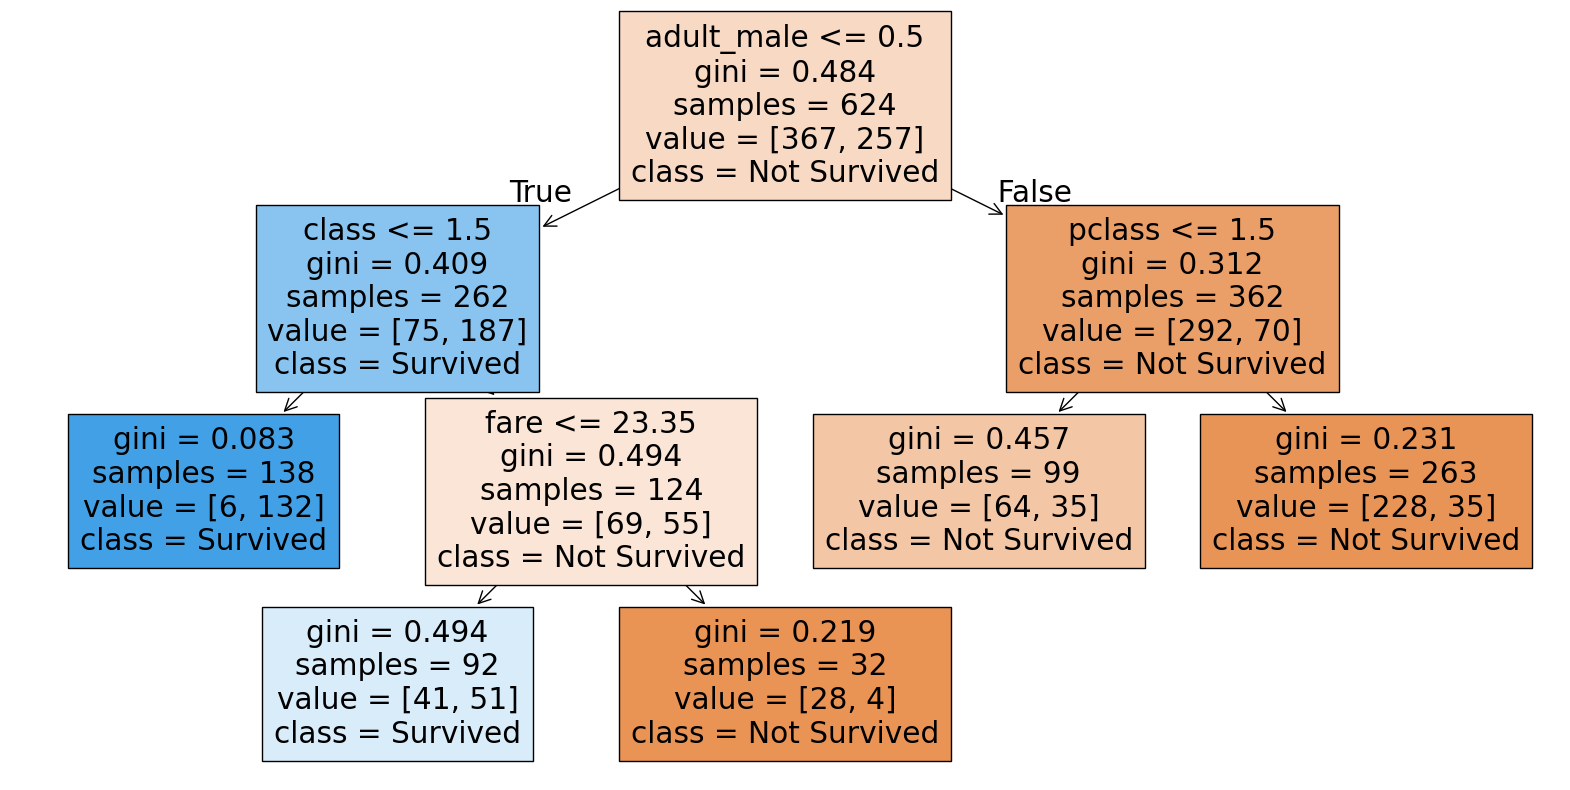

In [233]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    best_dt,
    feature_names=X_train.columns,
    class_names=["Not Survived", "Survived"],
    filled=True,
    max_depth=3
)

plt.show()



REGRESSION



In [ ]:
# 3. Regression
#    3.1 Load dataset
#    3.2 EDA
#    3.3 Train-test split
#    3.4 Baseline Decision Tree
#    3.5 Evaluation
#    3.6 Feature importance
#    3.7 Hyperparameter tuning
#    3.8 Actual vs predicted
#    3.9 Extrapolation experiment

In [238]:
df=pd.read_csv('/content/sample_data/california_housing_train.csv')


In [239]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [240]:
df.shape

(17000, 9)

In [241]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           17000 non-null  float64
 1   latitude            17000 non-null  float64
 2   housing_median_age  17000 non-null  float64
 3   total_rooms         17000 non-null  float64
 4   total_bedrooms      17000 non-null  float64
 5   population          17000 non-null  float64
 6   households          17000 non-null  float64
 7   median_income       17000 non-null  float64
 8   median_house_value  17000 non-null  float64
dtypes: float64(9)
memory usage: 1.2 MB


<Axes: >

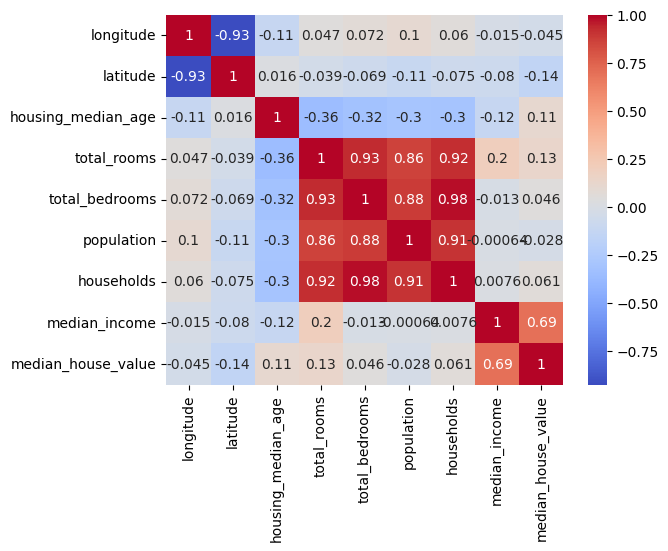

In [243]:
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')

In [244]:
X=df.drop('median_house_value',axis=1)
y=df['median_house_value']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Parameters
# max_depth
# criterion

# splitter

# min_samples_split
# min_samples_leaf

# min_weight_fraction_leaf

# max_features


# max_leaf_nodes

# min_impurity_decrease

# ccp_alpha

# monotonic_cst


In [248]:
from sklearn.tree import DecisionTreeRegressor

param_grid = {
    'max_depth': [3, 4, 5, 6, 8],
    'min_samples_split': [3, 5, 10],
    'min_samples_leaf': [1, 5, 10]
}

grid=GridSearchCV(
    DecisionTreeRegressor(),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error'
)
grid.fit(X_train,y_train)

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 8, 'min_samples_leaf': 10, 'min_samples_split': 10}
-4201055668.018985


In [249]:
best_dt = grid.best_estimator_

y_pred = best_dt.predict(X_test)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Train R²:", best_dt.score(X_train, y_train))
print("Test R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)

Train R²: 0.7560879692545636
Test R²: 0.6971020973511357
MAE: 44524.40683983515
MSE: 4173584217.7503147
RMSE: 64603.283335681284


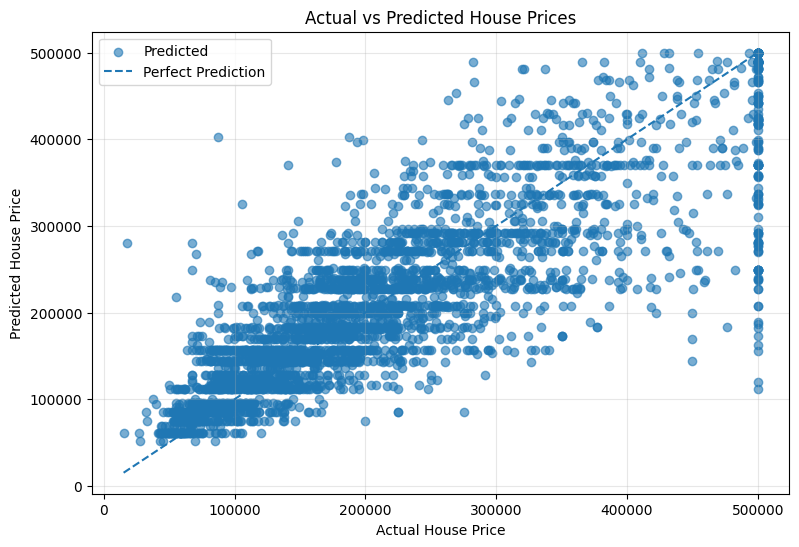

In [251]:
plt.figure(figsize=(9, 6))

plt.scatter(
    y_test,
    y_pred,
    label='Predicted',
    alpha=0.6
)

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--',
    label='Perfect Prediction'
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

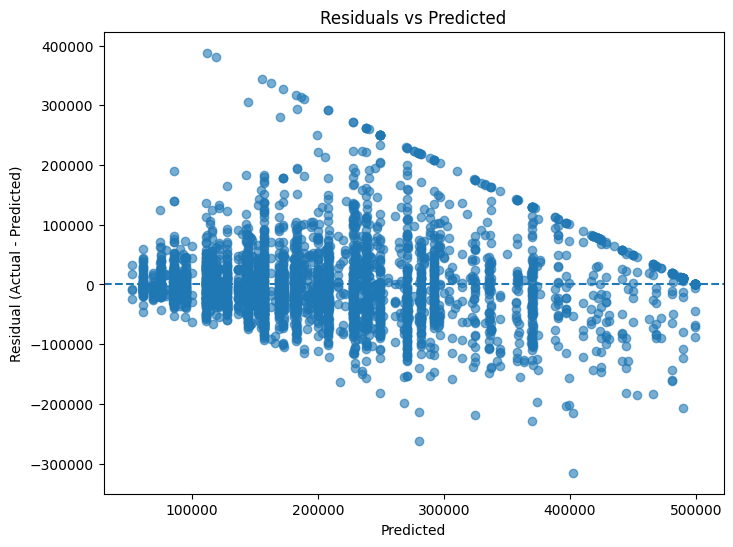

In [252]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, linestyle='--')

plt.xlabel("Predicted")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residuals vs Predicted")
plt.show()

In [ ]:
# Classification
# ✓ EDA
# ✓ Correlation
# ✓ Baseline
# ✓ Feature importance
# ✓ Feature selection
# ✓ Overfitting
# ✓ Pre-pruning
# ✓ Post-pruning
# ✓ Hyperparameter tuning
# ✓ Evaluation

# Regression
# ✓ DecisionTreeRegressor
# ✓ Hyperparameter tuning
# ✓ R² / MAE / MSE / RMSE
# ✓ Overfitting analysis
# ✓ Actual vs predicted
# → Residual analysis
# → Extrapolation